In [6]:
# Imports

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# get_data

In [9]:
# Download the file if it doesn't exist
TEX_FILE = 'SCPUnion2.1_AllSNe.tex'
TEX_URL = 'https://supernova.lbl.gov/Union/figures/SCPUnion2.1_AllSNe.tex'

# Creates an array with each row being a supernova, and each column being a different property (all are unitless).
class SNData:
    def __init__(self, filepath):
        SN        = [] # Name
        z         = [] # Redshift
        m_b       = [] # Magnitude in the B band
        x1        = [] # Stretch
        color     = [] # Color (how red or blue it is)
        mu        = [] # Distance modulus
        p_low_mass_host   = [] # Probability that the supernova was hosted by a low-mass galaxy
        m_b_err   = [] # Error in magnitude in the B band
        x1_err    = [] # Error in stretch
        color_err = [] # Error in color
        mu_err    = [] # Error in distance modulus

        with open(filepath, 'r') as f:
            for line in f:
                # Remove the \\ at the end and split by &
                line = line.strip().replace('\\\\', '')
                cols = line.split('&')
                if len(cols) < 7:
                    continue

                SN.append(cols[0].strip())
                z.append(float(cols[1].strip()))

                # Columns 3-6 look like "16.86(0.19)" where 16.86 is the value and 0.19 is the error.
                # We loop over all four of these columns at once. Each iteration gives us:
                # col_list - the list we want to add the main value to (e.g. m_b)
                # err_list - the list we want to add the error to (e.g. m_b_err)
                # raw - the raw text from that column (e.g. "16.86(0.19)")
                for col_list, err_list, raw in [
                    (m_b,   m_b_err,   cols[2].strip()),
                    (x1,    x1_err,    cols[3].strip()),
                    (color, color_err, cols[4].strip()),
                    (mu,    mu_err,    cols[5].strip()),
                ]:
                    if raw == r'\nodata':
                        col_list.append(np.nan)
                        err_list.append(np.nan)
                    else:
                        # Split "16.86(0.19)" into ["16.86", "0.19)"]
                        parts = raw.split('(')
                        value = float(parts[0])
                        # Strip the closing ) before converting the error to a float
                        error = float(parts[1].strip(')'))
                        col_list.append(value)
                        err_list.append(error)

                raw_sig = cols[6].strip()
                p_low_mass_host.append(np.nan if raw_sig == r'\nodata' else float(raw_sig))

        # Store everything as a numpy structured array so you can do data['m_b'] etc.
        self.array = np.array(
            list(zip(SN, z, m_b, x1, color, mu, p_low_mass_host,
                     m_b_err, x1_err, color_err, mu_err)),
            dtype=[
                ('SN','U20'),
                ('z','f8'),
                ('m_b','f8'),
                ('x1','f8'),
                ('color','f8'),
                ('mu','f8'),
                ('p_low_mass_host','f8'),
                ('m_b_err','f8'),
                ('x1_err','f8'),
                ('color_err','f8'),
                ('mu_err','f8'),
            ]
        )

    def __getitem__(self, col):
        return self.array[col]

# Austin - added this here so that way Joseph and I don't have to manually format this data ourselves each time
def load_sn_arrays(tex_file=TEX_FILE):
    """
    Return SN Ia arrays ready for fitting: finite z, mu, errors; z > 0.
    Uncertainty is mu_err
    """
    sn = SNData(tex_file)
    z = sn["z"]
    mu = sn["mu"]
    mu_err = sn["mu_err"]
    valid = (
        np.isfinite(z)
        & np.isfinite(mu)
        & np.isfinite(mu_err)
        & (z > 0)
        & (mu_err > 0)
    )
    z = z[valid]
    mu = mu[valid]
    mu_err = mu_err[valid]
    return z, mu, mu_err


data = SNData(TEX_FILE)

In [10]:
# cos_func

Using 714 supernovae across all valid z > 0 values
Best fit (flat LCDM, free H0): OmegaM=0.2919, OmegaA=0.7081, H0=69.538 km/s/Mpc
chi^2 = 1221.79, chi^2_red = 1.716


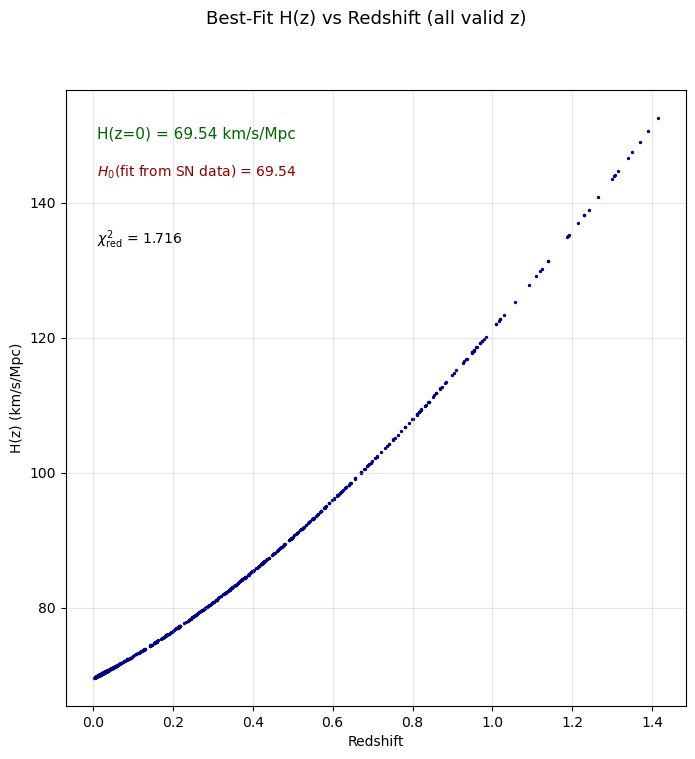

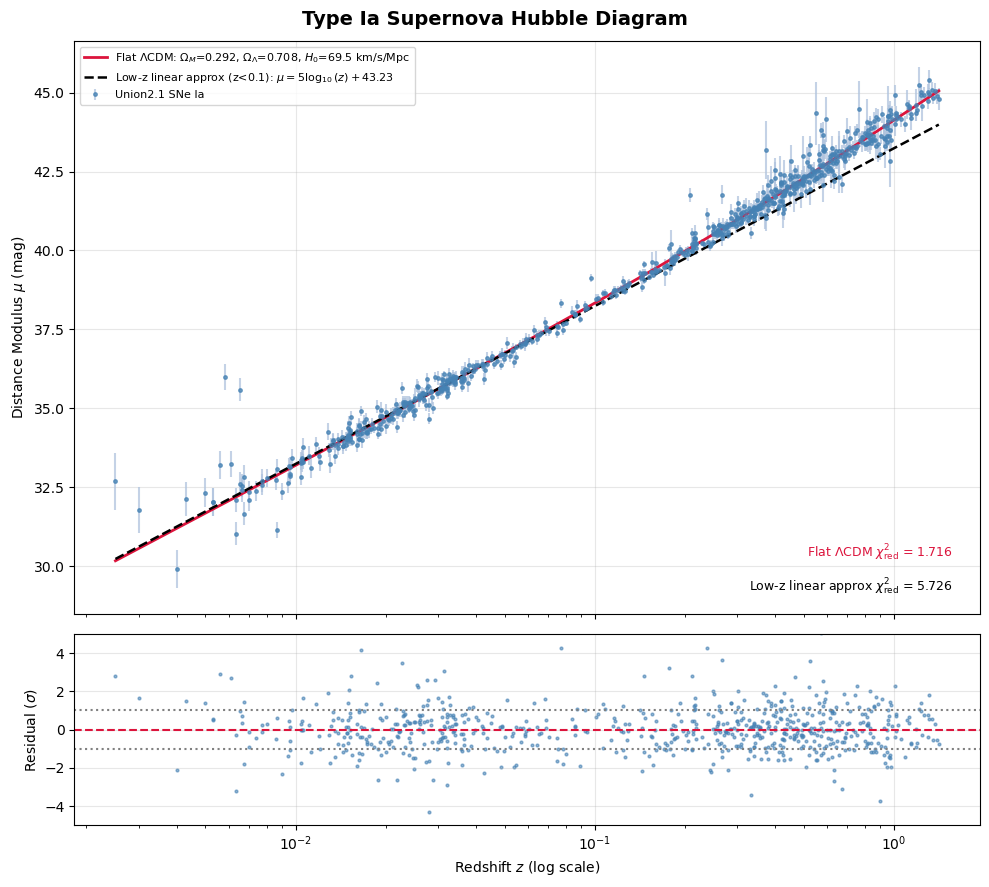

In [11]:
from get_data import load_sn_arrays
from scipy.optimize import minimize
from scipy.constants import c
from scipy.integrate import quad
C_KM_S = c / 1e3

# --- 1. Load cleaned SN Ia data ---
z, mu, mu_err = load_sn_arrays()


def adv_h_calc(z_values, OmegaM, OmegaA, H0):
    '''
    This function takes redshift, OmegaM, OmegaA, and H0
    and returns the Hubble parameter as a function of redshift.
    It assumes flat curvature of spacetime (OmegaK = 0),
    but allows other values to test alternatives.
    '''
    OmegaK = 1 - (OmegaM + OmegaA)
    inside = (OmegaM * (1 + z_values) ** 3) + (OmegaK * (1 + z_values) ** 2) + OmegaA
    Hz = H0 * np.sqrt(inside)
    return Hz

def mu_model(z_values, OmegaM, OmegaA, H0):
    """Distance-modulus prediction from (OmegaM, OmegaA, H0)."""
    OmegaK = 1 - (OmegaM + OmegaA)

    z_sorted_idx = np.argsort(z_values)
    z_sorted = z_values[z_sorted_idx]
    # Integrate from z=0 (prepend 0). Using only data z_min as the lower limit
    # makes the first trapezoid start at z_min, leaves χ(z_min)=0 and d_L≈0 → invalid μ.
    z_grid = np.concatenate(([0.0], z_sorted))
    e2 = (OmegaM * (1 + z_grid) ** 3) + (OmegaK * (1 + z_grid) ** 2) + OmegaA
    if np.any(e2 <= 0) or H0 <= 0:
        return None

    inv_e = 1.0 / np.sqrt(e2)
    dz = np.diff(z_grid)
    # Trapezoid cumulative integral of dz/E(z) from 0 to z_grid[j].
    cum_int = np.concatenate(([0.0], np.cumsum(0.5 * (inv_e[1:] + inv_e[:-1]) * dz)))
    chi_at_data = cum_int[1:]  # χ(z) at each z_sorted

    if np.isclose(OmegaK, 0.0):
        d_m = chi_at_data
    elif OmegaK > 0:
        sqrt_ok = np.sqrt(OmegaK)
        d_m = np.sinh(sqrt_ok * chi_at_data) / sqrt_ok
    else:
        sqrt_abs_ok = np.sqrt(-OmegaK)
        d_m = np.sin(sqrt_abs_ok * chi_at_data) / sqrt_abs_ok

    d_l_sorted = (C_KM_S / H0) * (1 + z_sorted) * d_m
    if np.any(d_l_sorted <= 0):
        return None

    mu_sorted = 5 * np.log10(d_l_sorted) + 25
    mu_pred = np.empty_like(mu_sorted)
    mu_pred[z_sorted_idx] = mu_sorted
    return mu_pred


def chi_squared_flat(params, z_values, mu_obs, mu_unc):
    """
    Flat LCDM with OmegaLambda = 1 - OmegaM.
    Fit both OmegaM and H0 directly to the Union2.1 distance-modulus data.
    """
    OmegaM, H0 = params
    OmegaA = 1.0 - OmegaM
    if OmegaM < 0 or OmegaA < 0 or H0 <= 0:
        return 1e30
    mu_pred = mu_model(z_values, OmegaM, OmegaA, H0)
    if mu_pred is None or not np.all(np.isfinite(mu_pred)):
        return 1e30
    residuals = (mu_obs - mu_pred) / mu_unc
    return np.sum(residuals ** 2)


# --- 3. Fit flat LCDM parameters using all valid redshifts from load_sn_arrays ---
z_fit = z
mu_fit = mu
mu_err_fit = mu_err
print(f"Using {len(z_fit)} supernovae across all valid z > 0 values")

result = minimize(
    chi_squared_flat,
    x0=np.array([0.30, 70.0]),
    args=(z_fit, mu_fit, mu_err_fit),
    method="L-BFGS-B",
    bounds=[(0.05, 0.95), (40.0, 100.0)],
)

if not result.success:
    raise RuntimeError(f"Parameter fit failed: {result.message}")

best_OmegaM, best_H0 = float(result.x[0]), float(result.x[1])
best_OmegaA = 1.0 - best_OmegaM
best_chi2 = result.fun
ndof = len(z_fit) - 2
reduced_chi2 = best_chi2 / ndof if ndof > 0 else np.nan

print(
    f"Best fit (flat LCDM, free H0): OmegaM={best_OmegaM:.4f}, "
    f"OmegaA={best_OmegaA:.4f}, H0={best_H0:.3f} km/s/Mpc"
)
print(f"chi^2 = {best_chi2:.2f}, chi^2_red = {reduced_chi2:.3f}")

Hz_array = adv_h_calc(z_fit, best_OmegaM, best_OmegaA, best_H0)
Hz_at_z0 = adv_h_calc(0.0, best_OmegaM, best_OmegaA, best_H0)


# --- 4. Plot H(z) using the best-fit cosmology ---
fig, ax1 = plt.subplots(1, figsize=(8, 8))
fig.suptitle("Best-Fit H(z) vs Redshift (all valid z)", fontsize=13)
ax1.scatter(z_fit, Hz_array, s = 2, color="navy")
ax1.annotate(f"H(z=0) = {Hz_at_z0:.2f} km/s/Mpc", xy=(0.05, 0.92),
             xycoords='axes fraction', fontsize=11, color='darkgreen')
ax1.annotate(r"$H_0$" + f"(fit from SN data) = {best_H0:.2f}", xy=(0.05, 0.86),
             xycoords='axes fraction', fontsize=10, color='darkred')
ax1.annotate(r"$\chi^2_{\text{red}}$" + f" = {reduced_chi2:.3f}", xy=(0.05, 0.75),
             xycoords='axes fraction', fontsize=10, color='black')
ax1.set_ylabel("H(z) (km/s/Mpc)")
ax1.set_xlabel("Redshift")
ax1.grid(True, alpha=0.3)
plt.show()


#5. Hubble Diagram: predicted distance modulus vs redshift
#   E(z) = sqrt( Omega_m*(1+z)^3 + Omega_k*(1+z)^2 + Omega_Lambda )
#   d_H  = c / H0
#   d_C  = d_H * integral_0^z  dz' / E(z')
#   d_L  = (1+z) * d_C
#   mu   = 5 * log10(d_L [Mpc]) + 25

def E_z(z_prime, OmegaM, OmegaA):
    """Dimensionless Hubble rate E(z) = H(z)/H0; the integrand's denominator."""
    OmegaK = 1.0 - OmegaM - OmegaA
    return np.sqrt(OmegaM * (1.0 + z_prime)**3 + OmegaK * (1.0 + z_prime)**2 + OmegaA)


def comoving_distance(z_obs, OmegaM, OmegaA, H0):
    """Comoving distance d_C = (c/H0) * integral_0^z dz'/E(z'), in Mpc."""
    d_H = C_KM_S / H0                                          # Hubble distance in Mpc
    integrand = lambda z_prime: 1.0 / E_z(z_prime, OmegaM, OmegaA)
    integral_value, _ = quad(integrand, 0.0, z_obs)            # quad integrates from 0 to z_obs
    return d_H * integral_value


def distance_modulus(z_obs, OmegaM, OmegaA, H0):
    """
    Predicted distance modulus at redshift z_obs.
      d_C = d_H * integral_0^z dz'/E(z')     [comoving distance]
      d_L = (1+z) * d_C                       [luminosity distance, flat space]
      mu  = 5 * log10(d_L [Mpc]) + 25         [distance modulus]
    """
    d_C = comoving_distance(z_obs, OmegaM, OmegaA, H0)
    d_L = (1.0 + z_obs) * d_C                 # luminosity distance in Mpc
    return 5.0 * np.log10(d_L) + 25.0         # +25 converts Mpc to the standard 10 pc baseline


#Compute predicted mu at each observed supernova redshift
mu_predicted_data = np.array([
    distance_modulus(z_i, best_OmegaM, best_OmegaA, best_H0)
    for z_i in z_fit
])

#Chi^2: sum of ((observed - predicted) / uncertainty)^2; chi^2_red ~ 1 means good fit
residuals       = (mu_fit - mu_predicted_data) / mu_err_fit
chi2_hubble     = np.sum(residuals**2)
ndof_hubble     = len(z_fit) - 2
chi2_red_hubble = chi2_hubble / ndof_hubble

#Smooth model curve: 300 log-spaced z values so the plotted line looks continuous
z_smooth  = np.logspace(np.log10(z_fit.min()), np.log10(z_fit.max()), 300)
mu_smooth = np.array([
    distance_modulus(z_i, best_OmegaM, best_OmegaA, best_H0)
    for z_i in z_smooth
])

# Simple low-redshift linear approximation:
low_z_limit = 0.1
low_z_mask = z_fit < low_z_limit
z_low = z_fit[low_z_mask]
mu_low = mu_fit[low_z_mask]
mu_err_low = mu_err_fit[low_z_mask]

if len(z_low) > 0:
    log_z_low = 5 * np.log10(z_low)
    weights_low = 1.0 / (mu_err_low ** 2)
    C_low = np.sum(weights_low * (mu_low - log_z_low)) / np.sum(weights_low)
    mu_simple_smooth = 5 * np.log10(z_smooth) + C_low

    # Chi^2_red for low-z linear approximation evaluated over ALL data points (1 free param: C_low)
    mu_lowz_all     = 5 * np.log10(z_fit) + C_low
    res_lowz_all    = (mu_fit - mu_lowz_all) / mu_err_fit
    chi2_lowz       = np.sum(res_lowz_all ** 2)
    ndof_lowz       = len(z_fit) - 1          # only C_low was fitted
    chi2_red_lowz   = chi2_lowz / ndof_lowz
else:
    C_low = np.nan
    mu_simple_smooth = np.full_like(z_smooth, np.nan)
    chi2_red_lowz = np.nan

# Plot: two panels sharing the same x-axis
fig2, (ax_hub, ax_res) = plt.subplots(2, 1, figsize=(10, 9), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
fig2.suptitle("Type Ia Supernova Hubble Diagram", fontsize=14, fontweight='bold')

# Top panel: data points with error bars, and the model curve on top
ax_hub.errorbar(z_fit, mu_fit, yerr=mu_err_fit, fmt='o', markersize=2.5,color='steelblue', ecolor='lightsteelblue', alpha=0.75, label="Union2.1 SNe Ia")
ax_hub.plot(z_smooth, mu_smooth, color='crimson', linewidth=2, label=rf"Flat $\Lambda$CDM: $\Omega_M$={best_OmegaM:.3f}, $\Omega_\Lambda$={best_OmegaA:.3f}, $H_0$={best_H0:.1f} km/s/Mpc")
ax_hub.plot(z_smooth, mu_simple_smooth, color='black', linestyle='--', linewidth=1.8, label=rf"Low-z linear approx (z<{low_z_limit}): $\mu = 5\log_{{10}}(z) + {C_low:.2f}$")
ax_hub.annotate(rf"Flat $\Lambda$CDM $\chi^2_{{\rm red}}$ = {chi2_red_hubble:.3f}", xy=(0.97, 0.10), xycoords='axes fraction', fontsize=9, ha='right', color='crimson')
ax_hub.annotate(rf"Low-z linear approx $\chi^2_{{\rm red}}$ = {chi2_red_lowz:.3f}",    xy=(0.97, 0.04), xycoords='axes fraction', fontsize=9, ha='right', color='black')
ax_hub.set_ylabel(r"Distance Modulus $\mu$ (mag)")
ax_hub.legend(fontsize=8)
ax_hub.grid(True, alpha=0.3)

# Bottom panel: residuals in units of sigma, should scatter around 0
ax_res.scatter(z_fit, residuals, s=4, color='steelblue', alpha=0.6)
ax_res.axhline(0,  color='crimson', linestyle='--')   # zero line
ax_res.axhline(+1, color='gray',    linestyle=':')    # ±1 sigma guides
ax_res.axhline(-1, color='gray',    linestyle=':')
ax_res.set_ylabel(r"Residual ($\sigma$)")
ax_res.set_xlabel(r"Redshift $z$ (log scale)")
ax_res.set_xscale('log')
ax_res.set_ylim(-5, 5)
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Plot Data

This is the code for the linear approximation for low redshifts. 

It solves for the hubble constant via this formula

$$H_0=\frac{c}{10^{\frac{C_{best}-25}{5}}}$$

where c is the speed of light in kilometers per second and $$C_{best}$$ is the constant value used in the linear interpolation

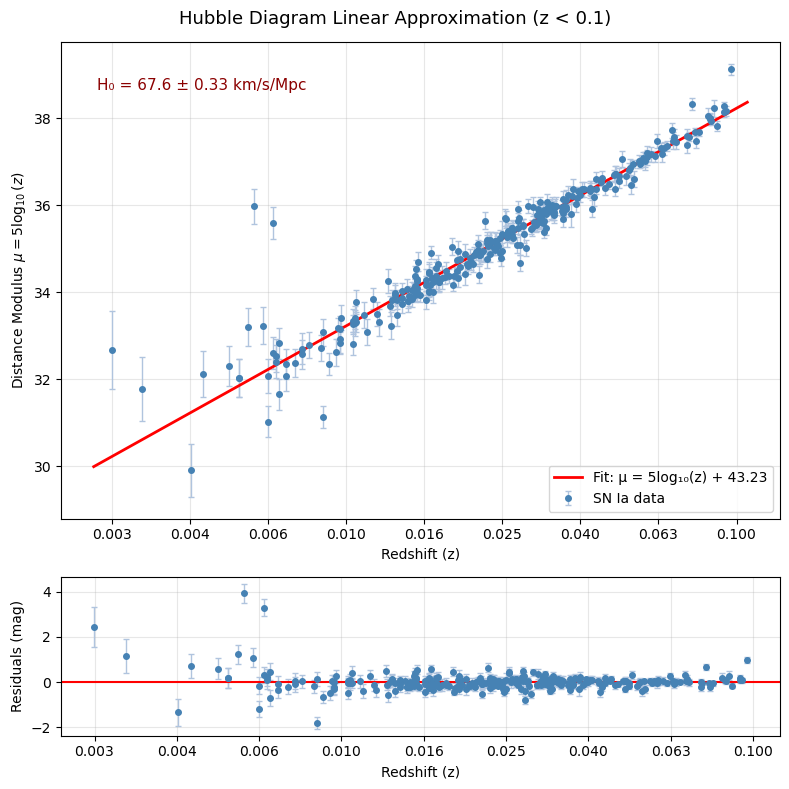

In [14]:
from get_data import TEX_FILE, TEX_URL, load_sn_arrays


class HubbleFitter:
    C_LIGHT = 3e5  # km/s
    
    def __init__(self, tex_file=TEX_FILE, z_max=0.1):
        '''
            First thing this function does is check if the data exists. if it doesn't, it returns an error.
            Secondly, it defines the maximum redshift (z_max) to be the value you add into the function (0.1 in this case).
            It also grabs the data from christans class in get_data and sets z (redshift), mu (distance_modulus), and dmu (uncertianty of the modulus) to the respective values in the data
            It then just sets all the constents you need (C_best, C_err, H0, H0_err, z_fit, mu_fit, dmu_fit) to 0 just incase they had a value already for some reason.
        '''
        if not os.path.exists(tex_file):
            print(f"{tex_file} not found. Download from: {TEX_URL}")
            raise SystemExit(1)

        self.z_max = z_max
        self.z, self.mu, self.dmu = load_sn_arrays(tex_file)

        self.C_best = self.C_err = self.H0 = self.H0_err = None
        self.z_fit = self.mu_fit = self.dmu_fit = None

    def fit(self):
        ''' 
            This function handles the fitting of the data and prepares it to be plotted
            Firstly, it filters out all of the objects that have a redshift of 0.1 or higher (this is because values above that start needing other parameters like dark energy)
            It then applies that mask to the fit of the redshift, distance modulus and the error of that modulus.
            Next, the code makes it so that the scale is put through a log based scale to make it more evident that a linear approach works
            It then finds the weights of those values because if a point has a greater uncertianty it shouldn't be affecting the line as much
            Next, it solves for the hubble constant (H0) via the formula shown above and then creates the error using the same formula except adding the error to C_best
        '''
        mask = self.z < self.z_max
        self.z_fit, self.mu_fit, self.dmu_fit = self.z[mask], self.mu[mask], self.dmu[mask]

        log_z = 5 * np.log10(self.z_fit)
        weights = 1.0 / self.dmu_fit**2
        self.C_best = np.sum(weights * (self.mu_fit - log_z)) / np.sum(weights)
        self.C_err  = 1.0 / np.sqrt(np.sum(weights))

        self.H0     = self.C_LIGHT / (10 ** ((self.C_best - 25) / 5))
        self.H0_err = self.H0 - self.C_LIGHT / 10 ** ((self.C_best + self.C_err - 25) / 5)
        return self

    def plot(self, save_path="hubble_fit.png", show=True):
        '''
            This code handles the plotting of the data so you can visually see it
            firstly, it redifnes log_z because the code needs to use it again and it can't grab it from the fit function
            It then defines the line for redshift using linspace and then mu_line just applies that to the distance modulus formula.
            Right after that, it makes the default graph and gives it a name.
            Then it just creates the key so that why the user knows what the points are signifying along side the best fit line
            The code uses tick_positions to overrights the default pyplot values so its more obvious the graph is on a log based scale to the user
            The rest of the code down to the line that says "residuals" basically just handles the visuals of the first graph
            The residiuals part figures out how well of a fit the line was. when you run the code, you'll notice no distnct patterns in the points which means this fit was pretty good.

        '''
        log_z = 5 * np.log10(self.z_fit)
        z_line = np.linspace(self.z_fit.min() * 0.9, self.z_fit.max() * 1.1, 200)
        mu_line = 5 * np.log10(z_line) + self.C_best

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1]})
        fig.suptitle(f"Hubble Diagram Linear Approximation (z < {self.z_max})", fontsize=13)

        ax1.errorbar(log_z, self.mu_fit, yerr=self.dmu_fit,
                     fmt='o', markersize=4, color='steelblue',
                     ecolor='lightsteelblue', elinewidth=1, capsize=2, label='SN Ia data')
        ax1.plot(5 * np.log10(z_line), mu_line, 'r-', linewidth=2,
                 label=f'Fit: μ = 5log₁₀(z) + {self.C_best:.2f}')
        tick_positions = [-13, -12, -11, -10, -9, -8, -7, -6, -5]

        ax1.set_xticks(tick_positions)
        ax1.set_xticklabels([f"{10**(t/5):.3f}" for t in tick_positions])
        ax1.set_ylabel(f"Distance Modulus" + r" $\mu = 5\log_{10}(z)$")
        ax1.set_xlabel("Redshift (z)")
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.annotate(f"H₀ = {self.H0:.1f} ± {self.H0_err:.2f} km/s/Mpc",
                     xy=(0.05, 0.9), xycoords='axes fraction', fontsize=11, color='darkred')

        residuals = self.mu_fit - (log_z + self.C_best)
        ax2.errorbar(log_z, residuals, yerr=self.dmu_fit,
                     fmt='o', markersize=4, color='steelblue',
                     ecolor='lightsteelblue', elinewidth=1, capsize=2)
        ax2.axhline(0, color='red', linewidth=1.5)
        ax2.set_xticks(tick_positions)
        ax2.set_xticklabels([f"{10**(t/5):.3f}" for t in tick_positions])
        ax2.set_ylabel("Residuals (mag)")
        ax2.set_xlabel("Redshift (z)")
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150)
        if show:
            plt.show()
        return fig, (ax1, ax2)

# this basically just runs the class if you're just running this part of the module
if __name__ == "__main__":
    fitter = HubbleFitter()
    fitter.fit()
    fitter.plot()
